In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# Load the dataset
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


# Task 1:

Using the pandas functions covered in class, answer the following:

• What is the total number of samples (rows) and potential features (columns) in this
dataset?

• Display the first 7 rows of the dataset to understand the structure.

• Display a random sample of 5 rows.
Why might it be better to look at a random sample rather than just the top rows? Answer
in two lines

In [67]:
print(df.shape)

print(f"Number of Samples (rows): {df.shape[0]}")
print(f"Potential Features: {df.shape[1]}")

(344, 7)
Number of Samples (rows): 344
Potential Features: 7


In [68]:
df.head(7)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female


In [69]:
df.sample(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
293,Gentoo,Biscoe,46.5,14.8,217.0,5200.0,Female
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN
249,Gentoo,Biscoe,50.0,15.3,220.0,5550.0,Male
238,Gentoo,Biscoe,46.2,14.5,209.0,4800.0,Female
38,Adelie,Dream,37.6,19.3,181.0,3300.0,Female


Why random sample is better than top rows:
The top rows may all belong to the same group or category (e.g., all "Adelie" penguins), giving a misleading picture of the data. A random sample is more likely to reflect the true variety and distribution across the full dataset.

# Task 2:

Before analyzing the data, we must check for missing information.

• Write the code to calculate the total number of missing values for each column.

• Which feature contains the highest number of missing values?

In [70]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [71]:
df.isnull().sum().idxmax()

'sex'

# Task 3:

Duplicate entries can hamper model performance.

• Check if there are any duplicate rows in the penguins dataset. How many duplicates are
there?

• Write the code to permanently remove any duplicate rows from your DataFrame.

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df.drop_duplicates(inplace=True)

# Task 4:

Let's profile the dataset to understand its distributions.

• Use the appropriate method to print a concise summary of the DataFrame, including the
data types of each column and non-null counts.

• Generate a statistical summary for the numerical columns.

• Based on your statistical summary, what is the maximum body_mass_g of a penguin in
this dataset? What is the average (mean) flipper_length_mm?

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [75]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [76]:
print(df['body_mass_g'].max())
print(df['flipper_length_mm'].mean())

6300.0
200.91520467836258


# Task 5:

Create a visualization to understand the distribution of penguin species.

• Use Seaborn to create a count plot for the species column.

• Which species is the most common in this dataset?

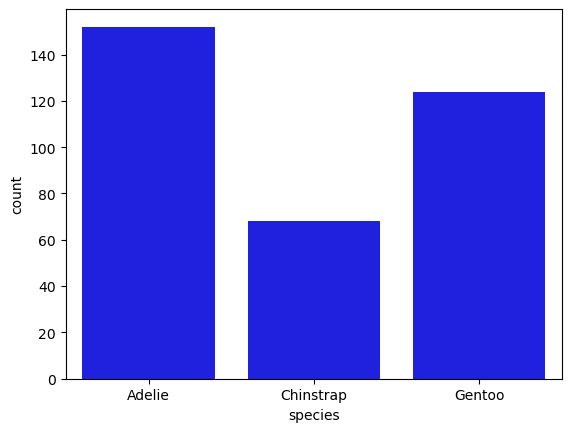

In [77]:
sns.countplot(data=df, x='species', color='blue')
plt.show()

# Task 6:

• Write the code to calculate the percentage distribution of the island column

In [78]:
(df['island'].value_counts() / len(df)) * 100

island
Biscoe       48.837209
Dream        36.046512
Torgersen    15.116279
Name: count, dtype: float64

# Task 7:

Let's visualize the gender distribution among the surveyed penguins.

• Extract the value counts for the sex column.

• Create a pie chart using Matplotlib showing the male vs. female distribution.

• Ensure the pie chart includes percentage labels with one decimal point (example
50.5%).

Add a title to your chart.

In [79]:
sex_count = df['sex'].value_counts()
sex_count


sex
Male      168
Female    165
Name: count, dtype: int64

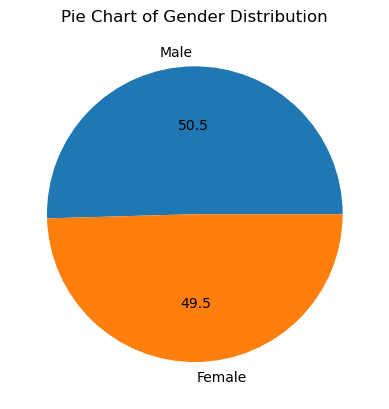

In [107]:

sex_percent = ((df['sex'].value_counts() / len(df)) * 100)

plt.pie(sex_percent, labels=sex_percent.index.tolist() ,autopct="%.1f")
plt.title('Pie Chart of Gender Distribution')
plt.show()